### Dataset Splitting and Organization

In [37]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define dataset paths
source_dir = "/kaggle/input/thermal-images-diseased-healthy-leaves-paddy/thermal images UL"
output_dir = "/kaggle/working/thermal_images_split"

# Define class names (same as your dataset)
classes = ['Blast', 'BLB', 'healthy', 'hispa', 'leaf folder', 'leaf spot']

# Function to split dataset into train, validation, and test
def prepare_data(source_dir, output_dir, classes, test_size=0.2, val_size=0.2):
    splits = ['train', 'validation', 'test']

    # Create directories for splits
    for split in splits:
        for cls in classes:
            os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

    # List all images and split data
    for cls in classes:
        class_dir = os.path.join(source_dir, cls)
        images = [os.path.join(class_dir, img) for img in os.listdir(class_dir) if img.endswith(('jpg', 'png'))]

        # Split into train, validation, and test sets
        train_val_images, test_images = train_test_split(images, test_size=test_size, random_state=42)
        train_images, val_images = train_test_split(train_val_images, test_size=val_size, random_state=42)

        # Copy images to respective directories
        for img_path in train_images:
            shutil.copy(img_path, os.path.join(output_dir, 'train', cls))
        for img_path in val_images:
            shutil.copy(img_path, os.path.join(output_dir, 'validation', cls))
        for img_path in test_images:
            shutil.copy(img_path, os.path.join(output_dir, 'test', cls))

    print("✅ Dataset preparation complete.")

# Run dataset preparation
prepare_data(source_dir, output_dir, classes)


✅ Dataset preparation complete.


### Dataset Preprocessing and Augmentation

In [38]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define batch size and image size
batch_size = 32
img_size = (224, 224)

# ✅ Data Augmentation for Training Set
datagen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,  # More rotation
    width_shift_range=0.3,  
    height_shift_range=0.3,  
    zoom_range=0.3,  
    horizontal_flip=True,
    vertical_flip=True,  # Add vertical flip
    brightness_range=[0.7, 1.3],  # Adjust brightness
    fill_mode='nearest'
)


# ✅ No Augmentation for Validation & Test Sets (Only Rescale)
datagen_val_test = ImageDataGenerator(rescale=1./255)

# ✅ Load training dataset (with augmentation)
train_generator = datagen_train.flow_from_directory(
    os.path.join(output_dir, 'train'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# ✅ Load validation dataset (no augmentation)
val_generator = datagen_val_test.flow_from_directory(
    os.path.join(output_dir, 'validation'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# ✅ Load test dataset (no augmentation)
test_generator = datagen_val_test.flow_from_directory(
    os.path.join(output_dir, 'test'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)


Found 403 images belonging to 6 classes.
Found 104 images belonging to 6 classes.
Found 129 images belonging to 6 classes.


In [39]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

# ✅ Define AlexNet Model in TensorFlow/Keras
def build_alexnet(input_shape=(224, 224, 3), num_classes=6):
    inputs = Input(shape=input_shape)

    x = layers.Conv2D(96, (11, 11), strides=4, activation='relu')(inputs)
    x = layers.MaxPooling2D((3, 3), strides=2)(x)

    x = layers.Conv2D(256, (5, 5), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((3, 3), strides=2)(x)

    x = layers.Conv2D(384, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(384, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((3, 3), strides=2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(4096, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(4096, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# ✅ Build and Compile Model
alexnet = build_alexnet()
alexnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ✅ Check and Use GPU if Available
device = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
print(f"Using device: {device}")


Using device: /GPU:0


In [40]:
# ✅ Compile the Model
alexnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ✅ Define Number of Epochs
num_epochs = 10


In [41]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = alexnet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,  # More epochs
    callbacks=[early_stop],  # Stop early if overfitting
    verbose=1
)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 408ms/step - accuracy: 0.2920 - loss: 1.7352 - val_accuracy: 0.3462 - val_loss: 1.6230
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 214ms/step - accuracy: 0.3187 - loss: 1.6409 - val_accuracy: 0.3462 - val_loss: 1.5566
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 205ms/step - accuracy: 0.3384 - loss: 1.6170 - val_accuracy: 0.3750 - val_loss: 1.5549
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 200ms/step - accuracy: 0.3400 - loss: 1.5528 - val_accuracy: 0.3942 - val_loss: 1.4957
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 217ms/step - accuracy: 0.3853 - loss: 1.5140 - val_accuracy: 0.4038 - val_loss: 1.4469
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.4281 - loss: 1.4929 - val_accuracy: 0.3173 - val_loss: 1.4648
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - accuracy: 0.3363 - loss: 1.5048 - val_accuracy: 0.3942 - val_loss: 1.5383
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 195ms/step - accuracy: 0.3599 - loss: 1.6118 - val_accuracy: 0

### Evaluate Model Performance

In [42]:
# ✅ Evaluate the model on the test set
test_loss, test_accuracy = alexnet.evaluate(test_generator, verbose=1)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7134 - loss: 0.9264
Test Accuracy: 0.7054
Test Loss: 0.9481


### Visualize Training Performance

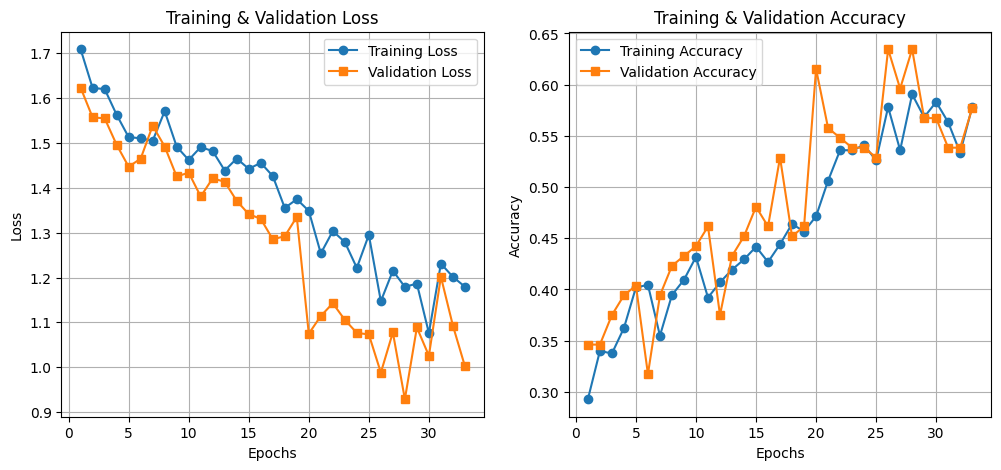

In [44]:
import matplotlib.pyplot as plt

# ✅ Extract loss & accuracy from history object
train_loss = history.history.get('loss', [])
val_loss = history.history.get('val_loss', [])
train_acc = history.history.get('accuracy', [])
val_acc = history.history.get('val_accuracy', [])

# ✅ Ensure lengths match before plotting
num_epochs = len(train_loss)  # Ensure the correct number of epochs
epochs_range = range(1, num_epochs + 1)

# ✅ Plot Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='s')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.grid(True)

# ✅ Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='s')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.grid(True)

plt.show()


In [46]:
# ✅ Save the trained model
alexnet.save("/kaggle/working/alexnet_thermal_model.h5")